In [19]:
!pip install ccxt==4.3.90 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 168.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 135.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 332.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 kB 277.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 155.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 133.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 143.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 kB 134.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.6/219.6 kB 134.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [20]:
!pip install ccxt pandas requests matplotlib seaborn scipy


📥 Fetching Fear & Greed data (full history)...
   FNG available: 2018-02-01 ~ 2026-03-06 (2952 days)

📥 Fetching BTC/USDT OHLCV from Kraken...
   Price available: 2024-03-16 ~ 2026-03-06 (721 days)

✅ Analysis period: 2024-03-23 ~ 2026-03-06 (713 days)

📊 [BTC-USDT] FNG <-> Return Correlation
  FNG <-> 1D Return: r = +0.0016, p = 0.9666  ❌ Not Significant
  FNG <-> 3D Return: r = +0.2384, p = 0.0000  ✅ Significant
  FNG <-> 7D Return: r = +0.4341, p = 0.0000  ✅ Significant

📊 [BTC-USDT] Lead-Lag Analysis (FNG -> 1D Return)
   Lag         r    p-value   Sig  Interpretation
------------------------------------------------------------
    -7    -0.0001     0.9975        FNG leads by 7d
    -6    +0.0093     0.8052        FNG leads by 6d
    -5    -0.0028     0.9407        FNG leads by 5d
    -4    +0.0060     0.8733        FNG leads by 4d
    -3    +0.0020     0.9582        FNG leads by 3d
    -2    -0.0093     0.8043        FNG leads by 2d
    -1    +0.0004     0.9915        FNG leads by

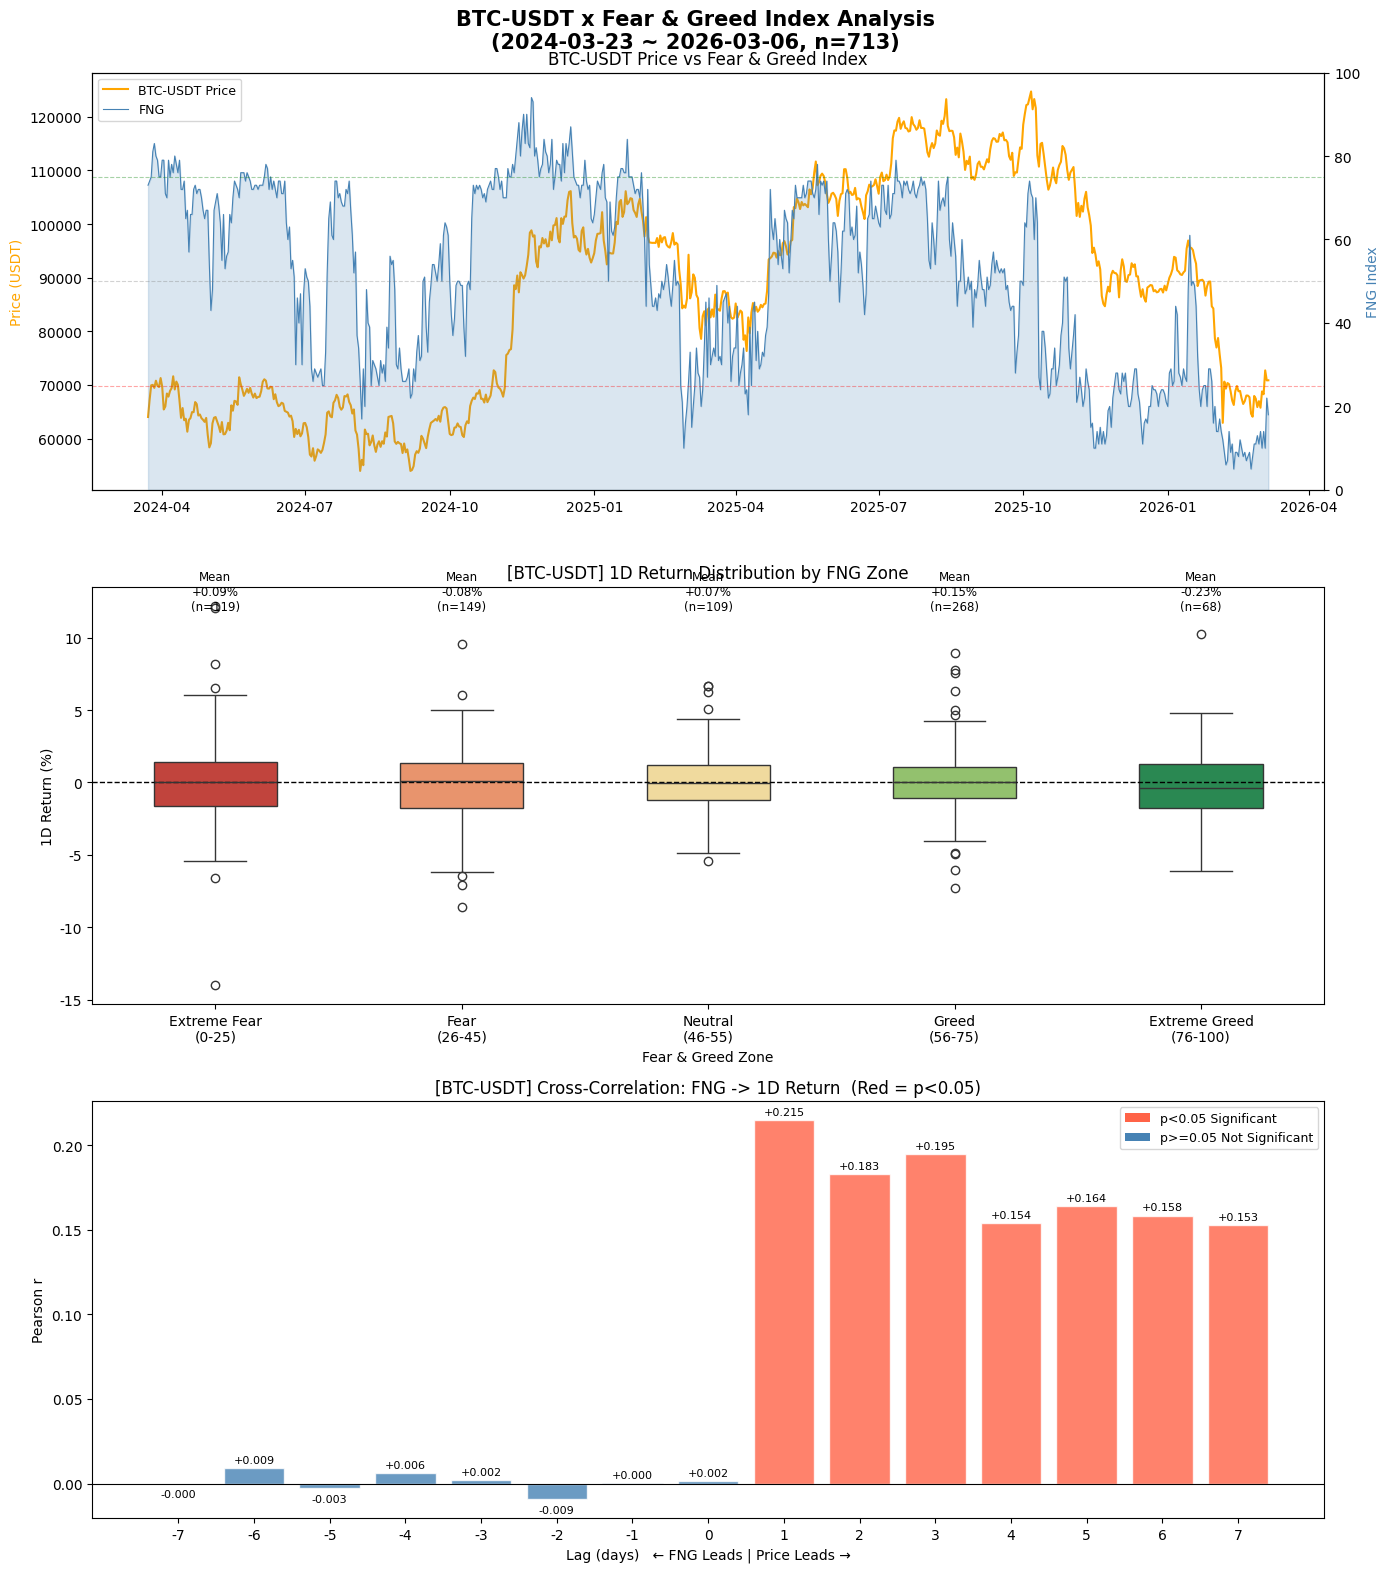


✅ Saved: fng_BTC-USDT_analysis.png


In [23]:
import ccxt
import pandas as pd
import requests
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import numpy as np
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# =====================
# ⚙️ 설정값 (여기만 수정)
# =====================
SYMBOL    = 'BTC/USDT'   # 분석할 코인 (예: 'ETH/USDT', 'SOL/USDT')
START_DATE = '2018-01-01' # 시작일 (None이면 가장 오래된 데이터부터)

# =====================
# 1. Fear & Greed 전체 데이터 (최대 가능 기간)
# =====================
print("📥 Fetching Fear & Greed data (full history)...")
url = "https://api.alternative.me/fng/?limit=0&format=json"  # limit=0 -> 전체
fng_data = requests.get(url).json()['data']
df_fng = pd.DataFrame(fng_data)
df_fng['date'] = pd.to_datetime(df_fng['timestamp'], unit='s').dt.date
df_fng['fng_value'] = df_fng['value'].astype(int)
df_fng = df_fng[['date', 'fng_value']].sort_values('date').reset_index(drop=True)
fng_start = df_fng['date'].min()
fng_end   = df_fng['date'].max()
print(f"   FNG available: {fng_start} ~ {fng_end} ({len(df_fng)} days)")

# =====================
# 2. 크라켄 OHLCV (전체 or START_DATE부터)
# =====================
print(f"\n📥 Fetching {SYMBOL} OHLCV from Kraken...")
exchange = ccxt.kraken()

if START_DATE is None:
    since_ms = exchange.parse8601('2018-01-01T00:00:00Z')
else:
    since_ms = exchange.parse8601(f'{START_DATE}T00:00:00Z')

all_ohlcv = []
while True:
    batch = exchange.fetch_ohlcv(SYMBOL, timeframe='1d', since=since_ms, limit=720)
    if not batch:
        break
    all_ohlcv += batch
    last_ts = batch[-1][0]
    since_ms = last_ts + 86400000  # 다음 날부터

    print(f"   Fetched {len(all_ohlcv)} candles... (last: {pd.to_datetime(last_ts, unit='ms').date()})")

    # 마지막 배치가 720개 미만이면 더 이상 데이터 없음
    if len(batch) < 720:
        break

    # 마지막 캔들이 오늘 이후면 종료
    if last_ts >= exchange.milliseconds():
        break

df_price = pd.DataFrame(all_ohlcv, columns=['timestamp','open','high','low','close','volume'])
df_price['date'] = pd.to_datetime(df_price['timestamp'], unit='ms').dt.date
df_price = df_price[['date','close']].drop_duplicates('date').reset_index(drop=True)
print(f"   Price available: {df_price['date'].min()} ~ {df_price['date'].max()} ({len(df_price)} days)")

# =====================
# 3. 병합
# =====================
df = pd.merge(df_price, df_fng, on='date', how='inner')
df['return_1d'] = df['close'].pct_change() * 100
df['return_3d'] = df['close'].pct_change(3) * 100
df['return_7d'] = df['close'].pct_change(7) * 100
df = df.dropna().reset_index(drop=True)
coin_name = SYMBOL.replace('/', '-')
print(f"\n✅ Analysis period: {df['date'].min()} ~ {df['date'].max()} ({len(df)} days)\n")

# =====================
# 4. 상관관계 출력
# =====================
print("=" * 60)
print(f"📊 [{coin_name}] FNG <-> Return Correlation")
print("=" * 60)
for col, label in [('return_1d','1D'),('return_3d','3D'),('return_7d','7D')]:
    r, p = stats.pearsonr(df['fng_value'], df[col])
    sig = "✅ Significant" if p < 0.05 else "❌ Not Significant"
    print(f"  FNG <-> {label} Return: r = {r:+.4f}, p = {p:.4f}  {sig}")

print()
print("=" * 60)
print(f"📊 [{coin_name}] Lead-Lag Analysis (FNG -> 1D Return)")
print("=" * 60)
print(f"{'Lag':>6}  {'r':>8}  {'p-value':>9}  {'Sig':>4}  Interpretation")
print("-" * 60)

lags = range(-7, 8)
lag_results = []
for lag in lags:
    if lag < 0:
        x, y = df['fng_value'].iloc[:lag].values, df['return_1d'].iloc[-lag:].values
        direction = f"FNG leads by {abs(lag)}d"
    elif lag > 0:
        x, y = df['fng_value'].iloc[lag:].values, df['return_1d'].iloc[:-lag].values
        direction = f"Price leads by {lag}d"
    else:
        x, y = df['fng_value'].values, df['return_1d'].values
        direction = "Concurrent"
    r, p = stats.pearsonr(x, y)
    sig = "✅" if p < 0.05 else "  "
    lag_results.append({'lag': lag, 'r': r, 'p': p, 'direction': direction})
    print(f"  {lag:>4}   {r:>+8.4f}  {p:>9.4f}  {sig:>4}  {direction}")

df_lag = pd.DataFrame(lag_results)
best = df_lag.loc[df_lag['r'].abs().idxmax()]
print(f"\n📌 Max correlation: lag={int(best['lag'])}d ({best['direction']}), r={best['r']:+.4f}, p={best['p']:.4f}")

# =====================
# 5. 시각화
# =====================
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle(f'{coin_name} x Fear & Greed Index Analysis\n({df["date"].min()} ~ {df["date"].max()}, n={len(df)})',
             fontsize=15, fontweight='bold')

# --- Chart 1: Price + FNG ---
ax1, ax2 = axes[0], axes[0].twinx()
ax1.plot(pd.to_datetime(df['date']), df['close'], color='orange', linewidth=1.5, label=f'{coin_name} Price')
ax2.fill_between(pd.to_datetime(df['date']), df['fng_value'], alpha=0.2, color='steelblue')
ax2.plot(pd.to_datetime(df['date']), df['fng_value'], color='steelblue', linewidth=0.8, label='FNG')
for lvl, col in [(25,'red'),(50,'gray'),(75,'green')]:
    ax2.axhline(y=lvl, color=col, linestyle='--', alpha=0.35, linewidth=0.8)
ax1.set_ylabel('Price (USDT)', color='orange'); ax2.set_ylabel('FNG Index', color='steelblue')
ax2.set_ylim(0, 100)
ax1.set_title(f'{coin_name} Price vs Fear & Greed Index', fontsize=12)
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=9)

# --- Chart 2: Boxplot by FNG zone ---
def fng_label(v):
    if v <= 25:   return 'Extreme Fear\n(0-25)'
    elif v <= 45: return 'Fear\n(26-45)'
    elif v <= 55: return 'Neutral\n(46-55)'
    elif v <= 75: return 'Greed\n(56-75)'
    else:         return 'Extreme Greed\n(76-100)'

df['fng_zone'] = df['fng_value'].apply(fng_label)
zone_order = ['Extreme Fear\n(0-25)','Fear\n(26-45)','Neutral\n(46-55)','Greed\n(56-75)','Extreme Greed\n(76-100)']
palette = ['#d73027','#fc8d59','#fee090','#91cf60','#1a9850']
sns.boxplot(data=df, x='fng_zone', y='return_1d', order=zone_order,
            palette=palette, ax=axes[1], width=0.5)
axes[1].axhline(y=0, color='black', linewidth=1.0, linestyle='--')
axes[1].set_xlabel('Fear & Greed Zone'); axes[1].set_ylabel('1D Return (%)')
axes[1].set_title(f'[{coin_name}] 1D Return Distribution by FNG Zone', fontsize=12)
ylim_top = axes[1].get_ylim()[1]
for i, zone in enumerate(zone_order):
    sub = df[df['fng_zone'] == zone]['return_1d']
    axes[1].text(i, ylim_top * 0.88,
                 f'Mean\n{sub.mean():+.2f}%\n(n={len(sub)})',
                 ha='center', fontsize=8.5)

# --- Chart 3: Lag bar ---
colors = ['tomato' if p < 0.05 else 'steelblue' for p in df_lag['p']]
bars = axes[2].bar(df_lag['lag'], df_lag['r'], color=colors, alpha=0.8, edgecolor='white')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Lag (days)   ← FNG Leads | Price Leads →')
axes[2].set_ylabel('Pearson r')
axes[2].set_title(f'[{coin_name}] Cross-Correlation: FNG -> 1D Return  (Red = p<0.05)', fontsize=12)
axes[2].set_xticks(list(lags))
for bar, row in zip(bars, lag_results):
    offset = 0.003 if row['r'] >= 0 else -0.008
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset,
                 f"{row['r']:+.3f}", ha='center', fontsize=8)
axes[2].legend(handles=[mpatches.Patch(facecolor='tomato', label='p<0.05 Significant'),
                         mpatches.Patch(facecolor='steelblue', label='p>=0.05 Not Significant')],
               loc='upper right', fontsize=9)

plt.tight_layout()
fname = f'fng_{coin_name}_analysis.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved: {fname}")